# 3. Класифікатор Naive Bayes

**Naive Bayes** — ймовірнісний класифікатор на основі теореми Баєса з припущенням про незалежність ознак. Обчислює P(клас|ознаки) через добуток ймовірностей кожної ознаки окремо.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score, recall_score, f1_score)
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

df = pd.read_csv('data_processed.csv')
X = df[['age', 'education-num', 'relationship']]
y = df['income']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Train: 39073 | Test: 9769


## 3.1 Навчання та оцінка

              precision    recall  f1-score   support

       <=50K       0.83      0.94      0.88      7431
        >50K       0.67      0.38      0.49      2338

    accuracy                           0.81      9769
   macro avg       0.75      0.66      0.68      9769
weighted avg       0.79      0.81      0.79      9769

Accuracy:  0.8073
Precision: 0.6707
Recall:    0.3832
F1-score:  0.4878


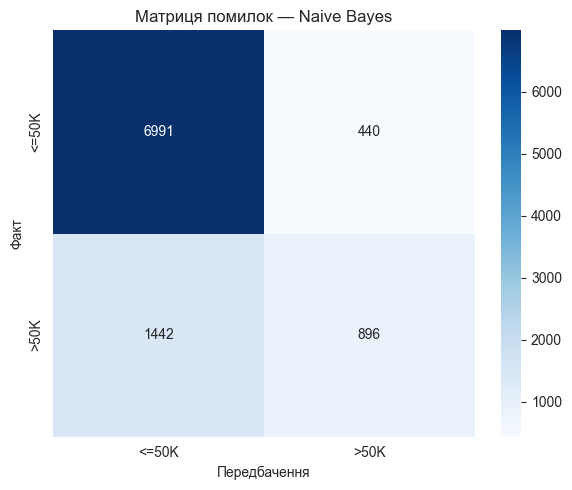

In [2]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")

# Матриця помилок
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
plt.title('Матриця помилок — Naive Bayes')
plt.xlabel('Передбачення'); plt.ylabel('Факт')
plt.tight_layout(); plt.show()

## 3.2 Експеримент з var_smoothing

`var_smoothing` додає частку найбільшої дисперсії до всіх ознак для стабілізації. Більше значення = більше згладжування.

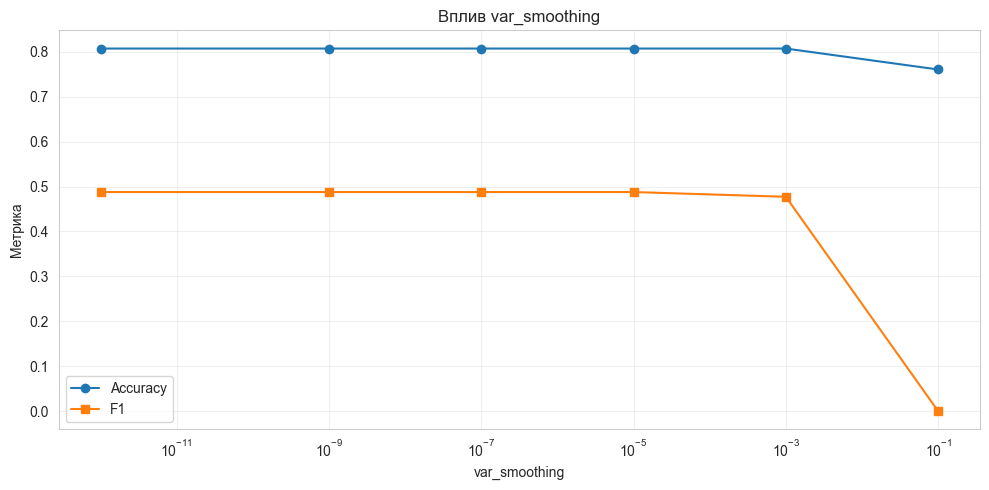

,var_smoothing,Accuracy,Precision,Recall,F1
0,1e-12,0.807350,0.670659,0.383234,0.487752
1,1e-09,0.807350,0.670659,0.383234,0.487752
2,1e-07,0.807350,0.670659,0.383234,0.487752
3,1e-05,0.807350,0.670659,0.383234,0.487752
4,1e-03,0.807350,0.680666,0.367408,0.477222
5,1e-01,0.760672,0.000000,0.000000,0.000000


In [3]:
smoothing_values = [1e-12, 1e-9, 1e-7, 1e-5, 1e-3, 1e-1]
results = []

for vs in smoothing_values:
    m = GaussianNB(var_smoothing=vs).fit(X_train, y_train)
    yp = m.predict(X_test)
    results.append({'var_smoothing': vs, 'Accuracy': accuracy_score(y_test, yp),
                    'Precision': precision_score(y_test, yp), 'Recall': recall_score(y_test, yp),
                    'F1': f1_score(y_test, yp)})

res_df = pd.DataFrame(results)

plt.figure(figsize=(10, 5))
plt.plot(res_df['var_smoothing'], res_df['Accuracy'], 'o-', label='Accuracy')
plt.plot(res_df['var_smoothing'], res_df['F1'], 's-', label='F1')
plt.xscale('log'); plt.xlabel('var_smoothing'); plt.ylabel('Метрика')
plt.title('Вплив var_smoothing'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

res_df['var_smoothing'] = res_df['var_smoothing'].map('{:.0e}'.format)
res_df

## Висновки

**Naive Bayes** припускає, що age, education-num та relationship **незалежні**, але це не так: старші люди частіше одружені (age ↔ relationship корелюють). Це порушення знижує якість моделі.

**Переваги:**
- Дуже швидкий — навчання миттєве навіть на великих даних
- Дає ймовірнісні оцінки (можна бачити "впевненість" моделі)
- Не потребує масштабування даних

**Недоліки:**
- Припущення про незалежність ознак порушується (вік і сімейний стан пов'язані)
- Gaussian NB припускає нормальний розподіл, а relationship — це код категорії (0-5), не неперервна величина
- Нижча точність порівняно з Decision Tree та kNN